# Section 5: Supervised Modeling, Model Evaluation, and Final Model Selection

**Project:** Predicting Restaurant Inspection Failures in New York City  
**Role:** Person D — Supervised Modeling + Final Model Selection  
**Primary Target:** `failed` where `1 = failed inspection` and `0 = passed inspection`

This notebook builds the final supervised learning pipeline for the project. It compares Logistic Regression, Random Forest, and Gradient Boosting, evaluates them with classification metrics, performs threshold tuning, and exports all report-ready figures and output files.

> **Business goal:** identify high-risk restaurants before inspection so inspection resources can be prioritized more efficiently.

## Table of Contents

1. Project Objective and Modeling Strategy  
2. Package Setup and Output Folders  
3. Data Loading and Basic Checks  
4. Leakage-Safe Feature Engineering  
5. Feature Selection and Train/Test Split  
6. Preprocessing Pipeline  
7. Model Training and Hyperparameter Tuning  
8. Model Comparison  
9. Threshold Optimization  
10. Final Model Selection  
11. Model Interpretation and Feature Importance  
12. Exported Outputs for GitHub and Report  
13. Final Summary

## 1. Project Objective and Modeling Strategy

The supervised learning task is a binary classification problem. A restaurant is labeled as failed if it receives a failing inspection outcome. Because failed inspections are less frequent than passing inspections, **accuracy alone is not sufficient**. A model that predicts most restaurants as passing can appear accurate but fail to identify truly risky restaurants.

Therefore, this notebook evaluates models using Accuracy, Precision, Recall, F1-score, and ROC-AUC. For this project, **Recall and F1-score are especially important**, because missing a truly failing restaurant can create public-health risk.

In [21]:
import sys
!{sys.executable} -m pip install scikit-learn

In [22]:
import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)

# Create output folders
os.makedirs("outputs", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

RANDOM_STATE = 42

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 3. Data Loading and Basic Checks

The model uses the final cleaned and integrated dataset, `restaurant_clean.csv`. This is the appropriate modeling file because earlier raw and intermediate files have already been merged, cleaned, and standardized.

The code below searches common local locations automatically, which makes the notebook easier to run on different computers.

In [23]:
SCRIPT_DIR = Path.cwd()

candidate_paths = [
    SCRIPT_DIR / "data" / "restaurant_clean.csv",
    SCRIPT_DIR / "data" / "processed" / "restaurant_clean.csv",
    SCRIPT_DIR / "restaurant_clean.csv",
    Path.home() / "Downloads" / "restaurant_clean.csv",
    Path.home() / "Desktop" / "restaurant_clean.csv",
    Path("/mnt/data/restaurant_clean.csv")
]

DATA_PATH = None
for p in candidate_paths:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Cannot find restaurant_clean.csv. Please place it in data/restaurant_clean.csv or the project root."
    )

print("Loaded data from:", DATA_PATH)
df = pd.read_csv(DATA_PATH, low_memory=False)
df["inspection_date"] = pd.to_datetime(df["inspection_date"], errors="coerce")

print("Data shape:", df.shape)
print("Date range:", df["inspection_date"].min(), "to", df["inspection_date"].max())
print("Target distribution:")
print(df["failed"].value_counts(dropna=False))
print("Failure rate:", round(df["failed"].mean(), 4))

df.head()

Loaded data from: C:\Users\11950\Desktop\restaurant_clean.csv
Data shape: (41556, 52)
Date range: 2023-01-03 00:00:00 to 2024-12-31 00:00:00
Target distribution:
failed
0    34074
1     7482
Name: count, dtype: int64
Failure rate: 0.18


,camis,inspection_date,dba,boro,zipcode,cuisine,score,grade,action,violation_count,...,score_trend,grade_available,has_yelp,is_first_inspection,has_history,cuisine_grouped,yelp_category_primary,white_pct,score_bucket,has_location
0,30075445,2023-08-01,MORRIS PARK BAKE SHOP,BRONX,10462,Bakery Products/Desserts,38.0,NaN,Violations were cited in the following area(s).,3,...,0.0,0,1,1,0,Bakery Products/Desserts,bakeries,0.179270,C,1
1,30075445,2023-08-22,MORRIS PARK BAKE SHOP,BRONX,10462,Bakery Products/Desserts,12.0,A,Violations were cited in the following area(s).,3,...,-26.0,1,1,0,1,Bakery Products/Desserts,bakeries,0.179270,A,1
2,30075445,2024-11-08,MORRIS PARK BAKE SHOP,BRONX,10462,Bakery Products/Desserts,10.0,A,Violations were cited in the following area(s).,3,...,-2.0,1,1,0,1,Bakery Products/Desserts,bakeries,0.179270,A,1
3,30191841,2023-04-23,D.J. REYNOLDS,MANHATTAN,10019,Irish,10.0,A,Violations were cited in the following area(s).,2,...,0.0,1,1,1,0,Other,irish,0.512163,A,1
4,30191841,2024-11-20,D.J. REYNOLDS,MANHATTAN,10019,Irish,24.0,NaN,Violations were cited in the following area(s).,6,...,14.0,0,1,0,1,Other,irish,0.512163,B,1


## 4. Leakage-Safe Feature Engineering

Target leakage is a major concern in supervised modeling. Variables such as current inspection score, grade, current violation count, and current critical count are directly connected to the inspection outcome. Using them would make the model unrealistically strong.

Instead, this section constructs predictors that would be available before or around the inspection context, such as prior inspection history, complaint environment, temporal patterns, weather, borough demographics, and Yelp visibility indicators.

In [24]:
df["poor_history_flag"] = ((df["prev_failed"] == 1) | (df["prev_score"] >= 28)).astype(int)

df["complaint_intensity"] = (
    df["food_complaints_total"].fillna(0)
    + df["rodent_complaints"].fillna(0)
    + df["food_safety_complaints"].fillna(0)
)

df["complaint_density"] = (
    df["food_complaints_total"].fillna(0) / df["total_population"].replace(0, np.nan)
) * 10000

df["high_complaint_flag"] = (
    df["food_complaints_total"] > df["food_complaints_total"].quantile(0.75)
).astype(int)

df["month_sin"] = np.sin(2 * np.pi * df["inspection_month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["inspection_month"] / 12)
df["dow_sin"] = np.sin(2 * np.pi * df["inspection_dow"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["inspection_dow"] / 7)
df["summer_flag"] = df["inspection_month"].isin([6, 7, 8]).astype(int)

df["log_yelp_reviews"] = np.log1p(df["yelp_reviews"])

df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Feature engineering complete.")
print("Current data shape:", df.shape)

Feature engineering complete.
Current data shape: (41556, 62)


## 5. Feature Selection and Train/Test Split

The model uses leakage-safe predictors only. Numerical variables are imputed and scaled; categorical variables are imputed and one-hot encoded.

A time-based split is used: inspections before 2024 are used for training and inspections in 2024 are used for testing. This better reflects the real-world setting where past data are used to predict future inspection risk.

In [25]:
numeric_features = [
    "prev_score", "prev_failed", "inspection_count", "poor_history_flag", "is_first_inspection", "has_history",
    "food_complaints_total", "rodent_complaints", "food_safety_complaints", "complaint_intensity", "complaint_density", "high_complaint_flag",
    "temp_mean", "precipitation_sum", "rain_sum", "snowfall_sum", "wind_speed_mean", "cloud_cover_mean",
    "month_sin", "month_cos", "dow_sin", "dow_cos", "summer_flag", "is_weekend",
    "median_household_income", "total_population", "white_pct", "has_yelp", "has_location", "log_yelp_reviews", "yelp_price"
]

categorical_features = ["boro", "cuisine_grouped", "yelp_category_primary"]

numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

model_df = df.dropna(subset=["failed", "inspection_date"]).copy()
train_df = model_df[model_df["inspection_date"] < "2024-01-01"].copy()
test_df = model_df[model_df["inspection_date"] >= "2024-01-01"].copy()

X_train = train_df[numeric_features + categorical_features]
y_train = train_df["failed"].astype(int)
X_test = test_df[numeric_features + categorical_features]
y_test = test_df["failed"].astype(int)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train failure rate:", round(y_train.mean(), 4))
print("Test failure rate:", round(y_test.mean(), 4))

Numeric features: 31
Categorical features: 3
Train shape: (17965, 34)
Test shape: (23591, 34)
Train failure rate: 0.1741
Test failure rate: 0.1846


## 6. Preprocessing Pipeline

A pipeline is used to ensure reproducibility and prevent data leakage. All preprocessing steps are learned from the training data and then applied to the test data.

Numerical features are median-imputed and standardized. Categorical features are most-frequent-imputed and one-hot encoded.

In [26]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=20)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", encoder)
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 7. Model Training and Hyperparameter Tuning

Three models are compared:

**Logistic Regression** provides interpretability and works well as a baseline.  
**Random Forest** captures nonlinear relationships and feature interactions.  
**Gradient Boosting** builds trees sequentially and can improve predictive performance.

GridSearchCV is used to tune hyperparameters using ROC-AUC as the optimization metric.

In [27]:
models = {
    "Logistic Regression": (
        LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=2000, random_state=RANDOM_STATE),
        {"model__C": [0.1, 1.0], "model__penalty": ["l1", "l2"]}
    ),
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        {"model__n_estimators": [100, 200], "model__max_depth": [8, 12], "model__min_samples_leaf": [5, 10]}
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.10], "model__max_depth": [2, 3]}
    )
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results = []
probs = {}
best_estimators = {}

for name, (clf, grid) in models.items():
    print(f"Training {name}...")
    pipe = Pipeline([("preprocessor", preprocessor), ("model", clf)])
    search = GridSearchCV(pipe, grid, scoring="roc_auc", cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)
    
    model = search.best_estimator_
    best_estimators[name] = model
    y_prob = model.predict_proba(X_test)[:, 1]
    probs[name] = y_prob
    y_pred = (y_prob >= 0.50).astype(int)
    
    results.append({
        "Model": name,
        "Best Params": search.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

metrics = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
metrics.to_csv("outputs/model_comparison_metrics.csv", index=False)
metrics

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...


,Model,Best Params,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,"{'model__C': 0.1, 'model__penalty': 'l2'}",0.622059,0.253326,0.537773,0.344412,0.630167
2,Gradient Boosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.815269,0.200000,0.000230,0.000459,0.615922
1,Random Forest,"{'model__max_depth': 8, 'model__min_samples_le...",0.651732,0.253982,0.457635,0.326668,0.613486


## 8. Model Comparison

The model comparison table summarizes performance at the default threshold of 0.50. In this project, Gradient Boosting has high accuracy but extremely low recall, meaning it fails to identify most failing restaurants. Logistic Regression offers the best practical balance across Recall, F1-score, and ROC-AUC.

In [28]:
metrics_plot = metrics.copy()
metrics_plot["Model"] = pd.Categorical(
    metrics_plot["Model"],
    categories=["Logistic Regression", "Random Forest", "Gradient Boosting"],
    ordered=True
)
metrics_plot = metrics_plot.sort_values("Model")

table_df = metrics_plot[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].copy()
for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    table_df[col] = table_df[col].astype(float).round(3)

table_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.622,0.253,0.538,0.344,0.630
1,Random Forest,0.652,0.254,0.458,0.327,0.613
2,Gradient Boosting,0.815,0.200,0.000,0.000,0.616


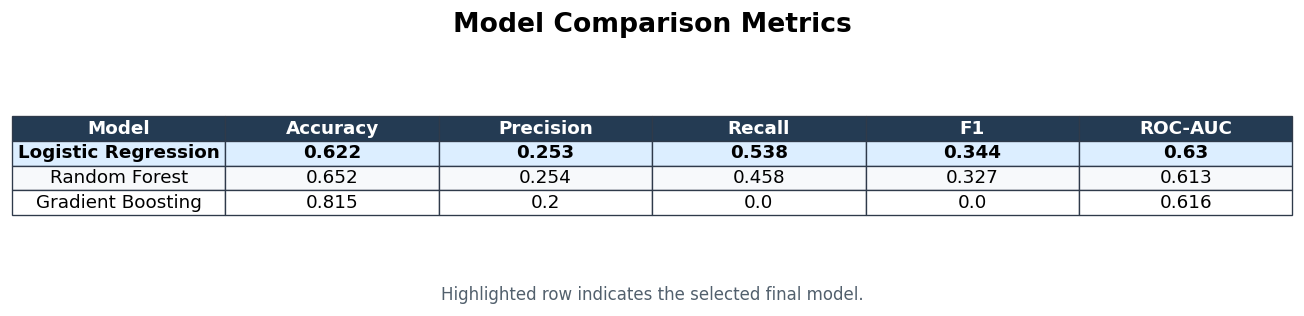

In [29]:
best_name = metrics.iloc[0]["Model"]

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.axis("off")

table = ax.table(
    cellText=table_df.values.tolist(),
    colLabels=table_df.columns.tolist(),
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.55)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#2F3A4A")
    cell.set_linewidth(0.8)
    if row == 0:
        cell.set_facecolor("#243B53")
        cell.set_text_props(color="white", weight="bold")
    elif table_df.iloc[row-1]["Model"] == best_name:
        cell.set_facecolor("#DCEEFF")
        cell.set_text_props(weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F7F9FB")
    else:
        cell.set_facecolor("white")

ax.set_title("Model Comparison Metrics", weight="bold", pad=18)
ax.text(0.5, -0.08, "Highlighted row indicates the selected final model.",
        transform=ax.transAxes, ha="center", va="top", fontsize=10, color="#52606D")
plt.tight_layout()
plt.savefig("figures/model_comparison_table.png", bbox_inches="tight")
plt.show()

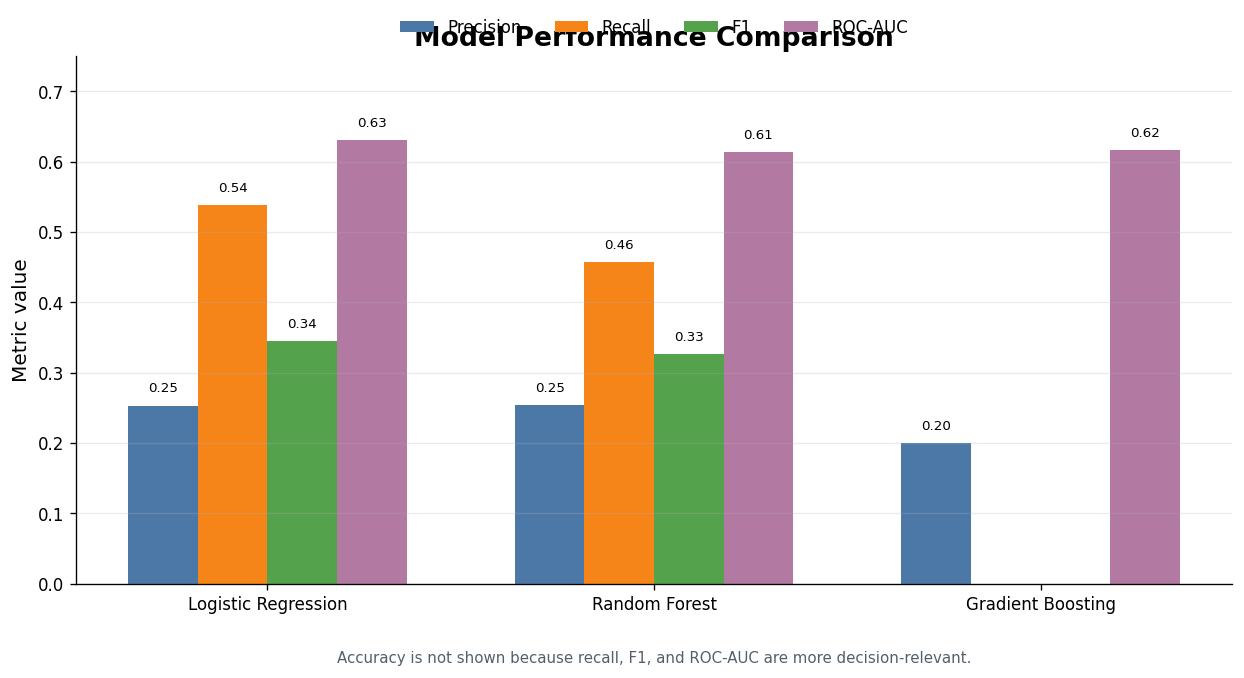

In [30]:
metric_cols = ["Precision", "Recall", "F1", "ROC-AUC"]
colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2"]

x = np.arange(len(metrics_plot["Model"]))
width = 0.18

fig, ax = plt.subplots(figsize=(10.5, 5.8))
for i, col in enumerate(metric_cols):
    bars = ax.bar(x + (i - 1.5) * width, metrics_plot[col], width, label=col, color=colors[i])
    for bar in bars:
        h = bar.get_height()
        if h > 0.025:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.015, f"{h:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_plot["Model"], rotation=0)
ax.set_ylim(0, 0.75)
ax.set_ylabel("Metric value")
ax.set_title("Model Performance Comparison", weight="bold")
ax.grid(axis="y", alpha=0.25)
ax.legend(ncol=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.10))
ax.text(0.5, -0.15, "Accuracy is not shown because recall, F1, and ROC-AUC are more decision-relevant.",
        transform=ax.transAxes, ha="center", fontsize=9, color="#52606D")
plt.tight_layout()
plt.savefig("figures/model_performance_comparison.png", bbox_inches="tight")
plt.show()

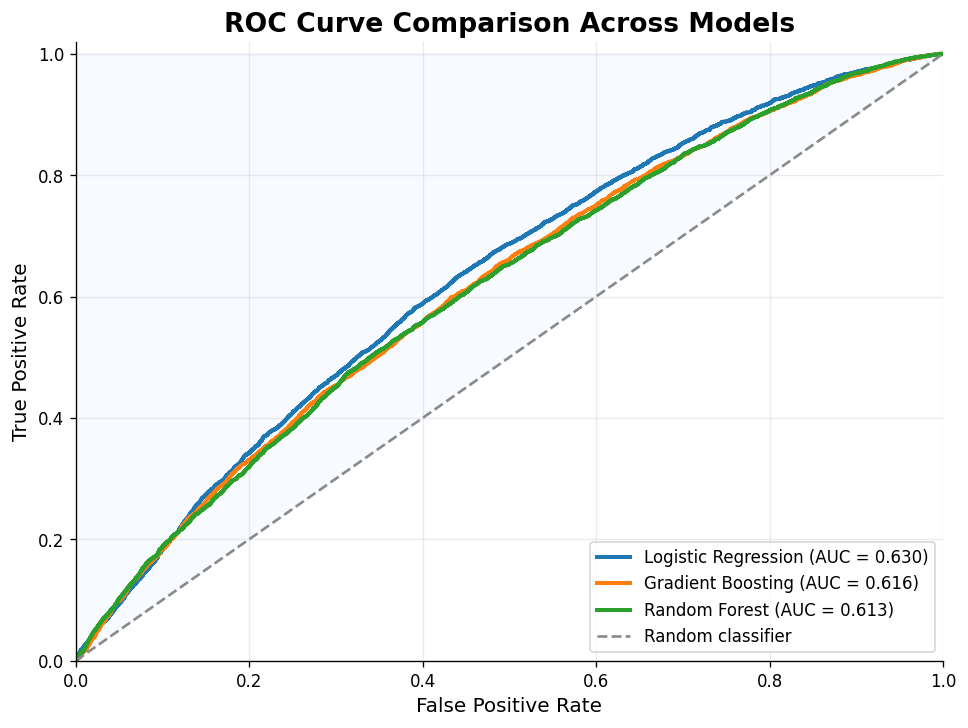

In [31]:
fig, ax = plt.subplots(figsize=(8.2, 6.2))
roc_colors = {
    "Logistic Regression": "#1F77B4",
    "Random Forest": "#2CA02C",
    "Gradient Boosting": "#FF7F0E"
}

for name in metrics.sort_values("ROC-AUC", ascending=False)["Model"]:
    prob = probs[name]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2.4, color=roc_colors.get(name, None), label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="#8A8A8A", linewidth=1.6, label="Random classifier")
ax.fill_between([0, 1], [0, 1], [1, 1], color="#EAF2FF", alpha=0.35)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison Across Models", weight="bold")
ax.grid(alpha=0.25)
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.savefig("figures/model_roc_comparison.png", bbox_inches="tight")
plt.show()

## 9. Threshold Optimization

The default threshold of 0.50 may not be optimal for imbalanced classification. Since identifying failing restaurants is more important than simply maximizing accuracy, the threshold is tuned to maximize F1-score, balancing Precision and Recall.

In [32]:
best_prob = probs[best_name]
threshold_rows = []

for t in np.arange(0.10, 0.91, 0.01):
    pred = (best_prob >= t).astype(int)
    threshold_rows.append({
        "threshold": t,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "accuracy": accuracy_score(y_test, pred)
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv("outputs/final_model_threshold_tuning.csv", index=False)

best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_threshold = best_row["threshold"]
final_pred = (best_prob >= best_threshold).astype(int)

print("Best threshold:", round(best_threshold, 2))
best_row

Best threshold: 0.47


threshold    0.470000
precision    0.244792
recall       0.636739
f1           0.353631
accuracy     0.570302
Name: 37, dtype: float64

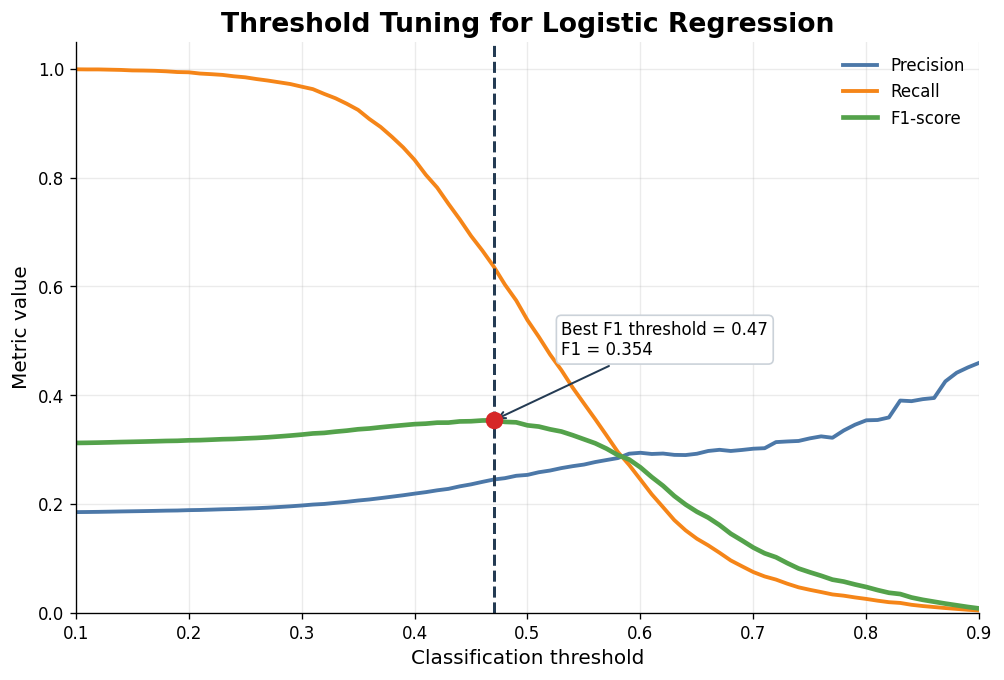

In [33]:
fig, ax = plt.subplots(figsize=(8.5, 5.8))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", linewidth=2.3, color="#4C78A8")
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", linewidth=2.3, color="#F58518")
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1-score", linewidth=2.8, color="#54A24B")
ax.axvline(best_threshold, linestyle="--", color="#243B53", linewidth=1.8)
ax.scatter([best_threshold], [best_row["f1"]], s=90, color="#D62728", zorder=5)
ax.annotate(
    f"Best F1 threshold = {best_threshold:.2f}\nF1 = {best_row['f1']:.3f}",
    xy=(best_threshold, best_row["f1"]),
    xytext=(best_threshold + 0.06, best_row["f1"] + 0.12),
    arrowprops=dict(arrowstyle="->", color="#243B53", lw=1.2),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#CBD2D9")
)
ax.set_xlim(0.10, 0.90)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Metric value")
ax.set_title(f"Threshold Tuning for {best_name}", weight="bold")
ax.grid(alpha=0.25)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.savefig("figures/final_model_threshold_tuning.png", bbox_inches="tight")
plt.show()

## 10. Final Model Selection

The final model is selected based on the project goal. Logistic Regression is selected because it provides the strongest balance between Recall, F1-score, ROC-AUC, and interpretability. This is important for a public-health context where model decisions should be understandable to regulators.

In [34]:
final_metrics = pd.DataFrame([{
    "Model": best_name,
    "Selected threshold": best_threshold,
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred, zero_division=0),
    "Recall": recall_score(y_test, final_pred, zero_division=0),
    "F1": f1_score(y_test, final_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, best_prob)
}])

final_metrics.to_csv("outputs/final_model_selected_metrics.csv", index=False)
final_metrics

,Model,Selected threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.47,0.570302,0.244792,0.636739,0.353631,0.630167


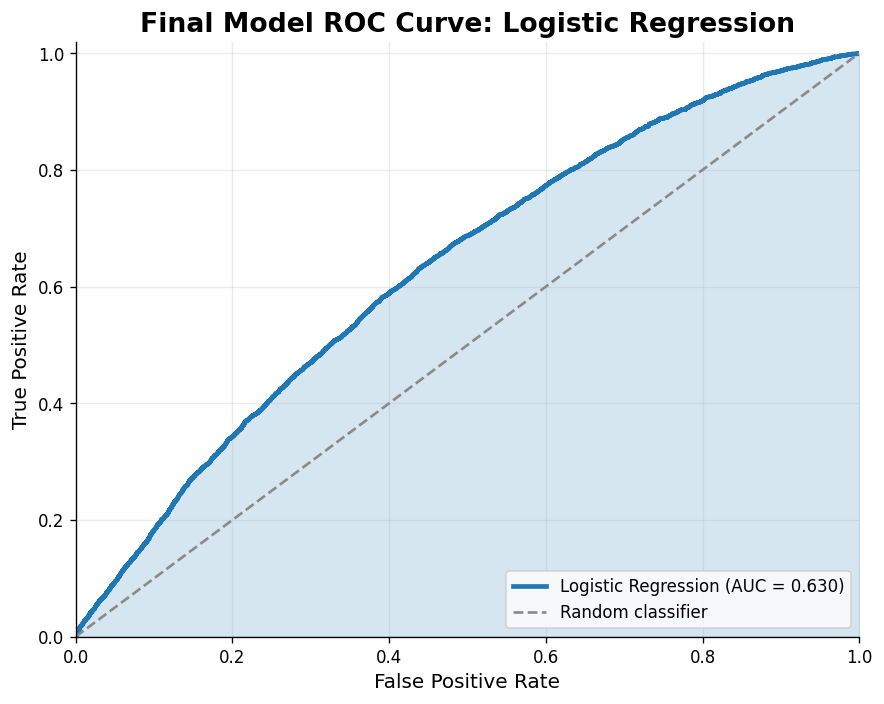

In [35]:
fig, ax = plt.subplots(figsize=(7.5, 6.0))
fpr, tpr, _ = roc_curve(y_test, best_prob)
auc = roc_auc_score(y_test, best_prob)
ax.plot(fpr, tpr, color="#1F77B4", linewidth=2.8, label=f"{best_name} (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="#8A8A8A", linewidth=1.6, label="Random classifier")
ax.fill_between(fpr, tpr, alpha=0.18, color="#1F77B4")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"Final Model ROC Curve: {best_name}", weight="bold")
ax.grid(alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/final_model_roc_curve.png", bbox_inches="tight")
plt.show()

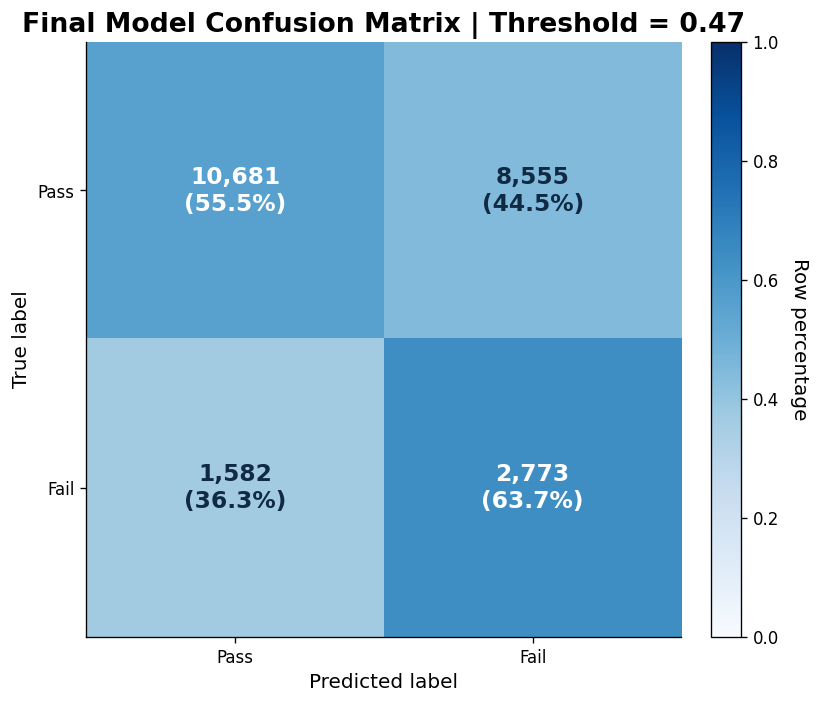

In [36]:
cm = confusion_matrix(y_test, final_pred)
row_pct = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7.2, 6.0))
im = ax.imshow(row_pct, cmap="Blues", vmin=0, vmax=1)

classes = ["Pass", "Fail"]
ax.set_xticks(np.arange(2))
ax.set_yticks(np.arange(2))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Final Model Confusion Matrix | Threshold = {best_threshold:.2f}", weight="bold")

for i in range(2):
    for j in range(2):
        text_color = "white" if row_pct[i, j] > 0.55 else "#102A43"
        ax.text(j, i, f"{cm[i, j]:,}\n({row_pct[i, j]:.1%})", ha="center", va="center", color=text_color, fontsize=14, weight="bold")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Row percentage", rotation=270, labelpad=18)
plt.tight_layout()
plt.savefig("figures/final_model_confusion_matrix.png", bbox_inches="tight")
plt.show()

## 11. Model Interpretation and Feature Importance

Because the final model is Logistic Regression, coefficients can be used to interpret which variables increase or decrease predicted failure risk. Positive coefficients increase predicted risk, while negative coefficients reduce predicted risk, holding other variables constant.

In [37]:
def get_feature_names_from_preprocessor(fitted_model, numeric_features, categorical_features):
    preprocessor_fitted = fitted_model.named_steps["preprocessor"]
    feature_names = []
    feature_names.extend([f"num__{c}" for c in numeric_features])
    try:
        cat_encoder = preprocessor_fitted.named_transformers_["cat"].named_steps["onehot"]
        cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
        feature_names.extend([f"cat__{c}" for c in cat_names])
    except Exception:
        pass
    return feature_names

final_model = best_estimators[best_name]
model_step = final_model.named_steps["model"]

if hasattr(model_step, "coef_"):
    feature_names = get_feature_names_from_preprocessor(final_model, numeric_features, categorical_features)
    importance_values = model_step.coef_[0]
    fi = pd.DataFrame({"feature": feature_names, "importance": importance_values})
    fi["absolute_importance"] = fi["importance"].abs()
    fi = fi.sort_values("absolute_importance", ascending=False).head(15)
    fi = fi.sort_values("absolute_importance", ascending=True)
    bar_colors = ["#D95F02" if v > 0 else "#1B9E77" for v in fi["importance"]]
    x_values = fi["importance"]
    xlabel = "Logistic Regression coefficient"
elif hasattr(model_step, "feature_importances_"):
    feature_names = get_feature_names_from_preprocessor(final_model, numeric_features, categorical_features)
    importance_values = model_step.feature_importances_
    fi = pd.DataFrame({"feature": feature_names, "importance": importance_values})
    fi["absolute_importance"] = fi["importance"].abs()
    fi = fi.sort_values("absolute_importance", ascending=False).head(15)
    fi = fi.sort_values("absolute_importance", ascending=True)
    bar_colors = "#4C78A8"
    x_values = fi["importance"]
    xlabel = "Feature importance"
else:
    fi = pd.DataFrame({"feature": [], "importance": [], "absolute_importance": []})

fi["feature_clean"] = (
    fi["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("cuisine_grouped_", "Cuisine: ", regex=False)
    .str.replace("yelp_category_primary_", "Yelp: ", regex=False)
    .str.replace("_", " ", regex=False)
)

fi.to_csv("outputs/final_model_feature_importance.csv", index=False)
fi.sort_values("absolute_importance", ascending=False).head(10)

,feature,importance,absolute_importance,feature_clean
43,cat__cuisine_grouped_Donuts,-1.222360,1.222360,Cuisine: Donuts
44,cat__cuisine_grouped_Hamburgers,-0.710796,0.710796,Cuisine: Hamburgers
41,cat__cuisine_grouped_Chinese,0.539749,0.539749,Cuisine: Chinese
49,cat__cuisine_grouped_Korean,0.525340,0.525340,Cuisine: Korean
90,cat__yelp_category_primary_restaurants,0.478875,0.478875,Yelp: restaurants
83,cat__yelp_category_primary_latin,-0.478673,0.478673,Yelp: latin
77,cat__yelp_category_primary_hotdogs,-0.469511,0.469511,Yelp: hotdogs
63,cat__yelp_category_primary_caribbean,-0.459167,0.459167,Yelp: caribbean
5,num__has_history,-0.446922,0.446922,has history
84,cat__yelp_category_primary_lounges,-0.446727,0.446727,Yelp: lounges


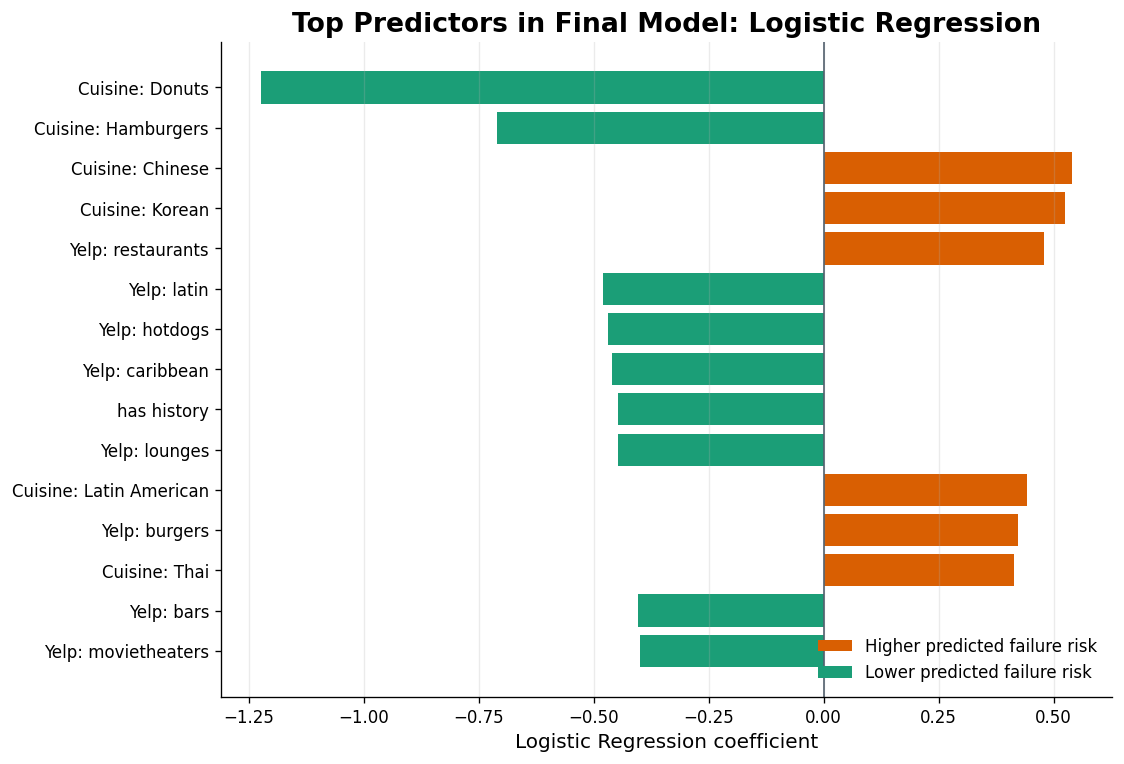

In [38]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.barh(fi["feature_clean"], x_values, color=bar_colors)
ax.axvline(0, color="#52606D", linewidth=1)
ax.set_xlabel(xlabel)
ax.set_ylabel("")
ax.set_title(f"Top Predictors in Final Model: {best_name}", weight="bold")
ax.grid(axis="x", alpha=0.25)

if hasattr(model_step, "coef_"):
    legend_elements = [
        Patch(facecolor="#D95F02", label="Higher predicted failure risk"),
        Patch(facecolor="#1B9E77", label="Lower predicted failure risk")
    ]
    ax.legend(handles=legend_elements, frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("figures/final_model_feature_importance.png", bbox_inches="tight")
plt.show()

## 12. Exported Outputs for GitHub and Report

This section exports three important CSV files for the Person D deliverable:

`model_metrics.csv` stores the comparison metrics for all supervised models.  
`best_model_summary.csv` stores the final selected model and its tuned-threshold performance.  
`prediction_sample.csv` provides example predictions with actual labels, predicted labels, and predicted probabilities.

In [39]:
model_metrics = metrics[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Best Params"]].copy()
model_metrics.to_csv("outputs/model_metrics.csv", index=False)

best_model_summary = final_metrics.copy()
best_model_summary["Reason"] = "Best balance of recall, F1-score, ROC-AUC, and interpretability"
best_model_summary.to_csv("outputs/best_model_summary.csv", index=False)

prediction_sample = X_test.copy().reset_index(drop=True).head(50)
prediction_sample.insert(0, "Actual_Label", y_test.reset_index(drop=True).head(50))
prediction_sample.insert(1, "Predicted_Label", final_pred[:50])
prediction_sample.insert(2, "Predicted_Probability", best_prob[:50])
prediction_sample.to_csv("outputs/prediction_sample.csv", index=False)

chart_files = [
    "figures/model_comparison_table.png",
    "figures/model_performance_comparison.png",
    "figures/model_roc_comparison.png",
    "figures/final_model_roc_curve.png",
    "figures/final_model_confusion_matrix.png",
    "figures/final_model_threshold_tuning.png",
    "figures/final_model_feature_importance.png",
]

checklist = pd.DataFrame({
    "chart_file": chart_files,
    "exists": [Path(f).exists() for f in chart_files],
    "recommended_use": [
        "Report Section 6 / PPT final model comparison",
        "PPT visual model comparison",
        "Report Section 5 ROC comparison",
        "Optional final model appendix or PPT backup",
        "Report Section 6 final model selection",
        "Report Section 5 threshold tuning",
        "Report Section 6 interpretation / PPT recommendation",
    ]
})
checklist.to_csv("outputs/chart_file_checklist.csv", index=False)

print("Person D output files exported successfully:")
print("- outputs/model_metrics.csv")
print("- outputs/best_model_summary.csv")
print("- outputs/prediction_sample.csv")
print("- outputs/final_model_feature_importance.csv")
print("- outputs/chart_file_checklist.csv")

Person D output files exported successfully:
- outputs/model_metrics.csv
- outputs/best_model_summary.csv
- outputs/prediction_sample.csv
- outputs/final_model_feature_importance.csv
- outputs/chart_file_checklist.csv


## 13. Final Summary

This notebook completed the supervised modeling section of the project. Three models were trained and compared: Logistic Regression, Random Forest, and Gradient Boosting. Although Gradient Boosting achieved high accuracy, it failed to identify most failing restaurants because of the imbalanced target distribution. Random Forest improved recall but did not outperform Logistic Regression overall.

Logistic Regression was selected as the final model because it achieved the strongest balance across Recall, F1-score, and ROC-AUC while remaining interpretable. Threshold tuning improved the model's ability to identify high-risk restaurants, which is directly aligned with the public-health goal of inspection prioritization.

The main deliverables from this notebook are the final model comparison table, ROC curves, threshold tuning plot, confusion matrix, feature importance plot, and CSV output files for GitHub submission. These outputs support the final report, presentation, and reproducible project repository.